# 1. Prerequisites

In [1]:
from utils.data import load_data, save_data
from utils.plotting import create_post_stim_raster_plot, map_colour_to_electrode

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import h5py
from tqdm import tqdm
from torch.utils.data import DataLoader, TensorDataset
import getpass

In [3]:
# Load the specific network here
Network = 5
DIV     = 21
group_data  = True
test_data = False

In [4]:
data = load_data(Network, DIV, group_data)
stimulation_parameters, stimulation_patterns, binned_spike_train_responses, stimulation_times, impedance_map, electrodes = data
print(f"Loaded data with response shape {binned_spike_train_responses.shape} and parameter shape {stimulation_parameters.shape}.")
if test_data:
    data = load_data(Network, DIV, group_data, test_mode=True)
    stimulation_parameters_test, stimulation_patterns_test, binned_spike_train_responses_test, stimulation_times_test, _, _ = data
else:
    binned_spike_train_responses_test = stimulation_patterns_test = stimulation_parameters_test = stimulation_times_test = None

Loaded data with response shape (35640, 160, 80) and parameter shape (35640, 2).


# 2. Model Definitions and Data Preparation

In [5]:
class CNN(nn.Module):
    """
    A simple CNN that takes an inputs of size (Batch, Channel, Height, Width). 
    The height in our task corresponds to the number of channels, the width to the number of time bins.
    """

    def __init__(self, n_outputs=1, n_base_channels= 32):
        super().__init__()

        self.convolutional_layers = nn.Sequential(
            nn.Conv2d(1, n_base_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(n_base_channels, n_base_channels*2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(n_base_channels*2, n_base_channels*4, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # This function pools an arbitrary input size to a predefined size
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))

        # output layers
        self.fully_connected_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_base_channels * 4 * 4 * 4, n_base_channels*8),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(n_base_channels*8, n_outputs),
        )

    def forward(self, x):
        x = self.convolutional_layers(x)
        x = self.adaptive_pool(x) 
        x = self.fully_connected_layers(x)
        return x

In [6]:
# Hyperparameters
# This is how often the model sees the full training dataset.  
n_epochs = 50

# The number of samples used for a single update step. Usually it is common to put this to large values from 32-1024. 
# It should be compared with the number of total training samples, and larger values will use more GPU memory. 
batch_size = 256

# Update step size which will be combined with the gradients. Small will have slow convergence, large will not converge. 
learning_rate = 1e-4 

# Here we define the used loss function. In this case it is cross entropy. The reduction we apply within the loop.
criterion = nn.CrossEntropyLoss(reduction='none')

# At last, we intialize the model and an optimizer, where latter takes care of combining learning rate and gradients.
n_classes = 16 # This is given by the data
# A CNN expects an input of shape (Batch, Channel, Height, Width). We have to manually add the channel dimension to the data:
if binned_spike_train_responses.ndim != 4:
    print(f"Initial input data size is {binned_spike_train_responses.shape}")
    binned_spike_train_responses = binned_spike_train_responses[:,None]
    print(f"Adjusted input data size is {binned_spike_train_responses.shape}")
if binned_spike_train_responses_test is not None and binned_spike_train_responses_test.ndim != 4: 
    binned_spike_train_responses_test = binned_spike_train_responses_test[:,None]
model = CNN(n_classes, n_base_channels=32)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
print(f"The model has {sum(p.numel() for p in model.parameters())} parameters.")

Initial input data size is (35640, 160, 80)
Adjusted input data size is (35640, 1, 160, 80)
The model has 621328 parameters.


In [7]:
# Data loading
# Pytorch dataloaders are parallel processing classes optimized for machine learning with Python. 
# It is recommended to use them. Here we set up such a dataloader. 
# We first split the training data into train and validation set. 
stimulation_patterns_one_hot = F.one_hot(torch.as_tensor(stimulation_patterns).long(), num_classes=n_classes).float()
val_frac = 0.1
n_val = int(binned_spike_train_responses.shape[0] * val_frac)
idx = torch.randperm(binned_spike_train_responses.shape[0])
val_idx = idx[:n_val]
trn_idx = idx[n_val:]
# Here, Z is any additional information we want to keep with the dataset split. 
Xtr, Ytr, Ztr = binned_spike_train_responses[trn_idx], stimulation_patterns_one_hot[trn_idx], stimulation_parameters[trn_idx]
Xval, Yval, Zval = binned_spike_train_responses[val_idx], stimulation_patterns_one_hot[val_idx], stimulation_parameters[val_idx]

# Here we initialize the dataloaders. 
train_dataset = TensorDataset(torch.as_tensor(Xtr, dtype=torch.float32), Ytr, torch.as_tensor(Ztr, dtype=torch.float32))
# Through deletion we can free up memory from our system
del Xtr, Ytr, Ztr
val_dataset   = TensorDataset(torch.as_tensor(Xval, dtype=torch.float32), Yval, torch.as_tensor(Zval, dtype=torch.float32))
del Xval, Yval, binned_spike_train_responses, stimulation_parameters, stimulation_patterns
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
if binned_spike_train_responses_test is not None:
    test_dataset   = TensorDataset(torch.as_tensor(binned_spike_train_responses_test, dtype=torch.float32))
    # Don't shuffle this data as else the predictions will be random w.r.t. the ground truth!
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    del binned_spike_train_responses_test, stimulation_parameters_test, stimulation_patterns_test
else:
    test_loader = None

# 3. Training and Validation Loop

In [8]:
import os
import getpass
import torch
import numpy as np
from tqdm import tqdm

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Running example model on {device}.")
model.to(device)

# Save the example model separately so it does NOT overwrite the final task model
best_model_path = f"/home/{getpass.getuser()}/best_model_example.pth"

# Load previous all-time best example loss, if available
if os.path.exists(best_model_path):
    checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        all_time_best_val_loss = checkpoint.get("best_val_loss", float("inf"))
        print(f"Previous all-time best example validation loss: {all_time_best_val_loss:.4f}")
        print(f"Previous all-time best example epoch: {checkpoint.get('best_epoch', 'unknown')}")
        print(f"Previous all-time best example run: {checkpoint.get('run_name', 'unknown')}")
    else:
        all_time_best_val_loss = float("inf")
        print("Found old-format best_model_example.pth without validation-loss metadata.")
        print("This run may overwrite it because the previous best loss is unknown.")
else:
    all_time_best_val_loss = float("inf")
    print("No previous all-time best example model found.")

run_name = "example_run"

pbar = tqdm(range(0, n_epochs), leave=False)

train_losses = np.zeros(n_epochs)
validation_losses = dict()
validation_predictions = dict()

# Track best within this run too
current_run_best_val_loss = float("inf")
current_run_best_epoch = None

for epoch in pbar:
    model.train()
    train_loss = 0.0

    for x, y, z in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        pred = model(x)
        loss = torch.mean(criterion(pred, y))
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses[epoch] = train_loss

    model.eval()
    val_loss = []
    val_pred = []

    with torch.no_grad():
        for x, y, z in val_loader:
            x, y = x.to(device), y.to(device)

            pred = model(x)
            loss = criterion(pred, y)

            val_loss.append(loss.detach().cpu().numpy())
            val_pred.append(torch.argmax(pred, dim=-1).detach().cpu().numpy())

    val_loss = np.concatenate(val_loss)
    val_pred = np.concatenate(val_pred)

    avg_val_loss = float(np.mean(val_loss))

    epoch_number = epoch + 1
    validation_losses[f"epoch_{epoch_number}"] = val_loss
    validation_predictions[f"epoch_{epoch_number}"] = val_pred

    # Best within this run
    if avg_val_loss < current_run_best_val_loss:
        current_run_best_val_loss = avg_val_loss
        current_run_best_epoch = epoch_number

    # All-time best example model across runs
    if avg_val_loss < all_time_best_val_loss:
        all_time_best_val_loss = avg_val_loss

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "best_val_loss": all_time_best_val_loss,
                "best_epoch": epoch_number,
                "run_name": run_name,
                "n_epochs": n_epochs,
            },
            best_model_path,
        )

        print(
            f"\nNew all-time best example model saved: "
            f"epoch {epoch_number}, val loss {all_time_best_val_loss:.4f}"
        )

    pbar.set_postfix(
        loss_train=f"{train_loss:.4f}",
        loss_val=f"{avg_val_loss:.4f}",
        best_this_run=f"{current_run_best_val_loss:.4f}",
        best_all_time=f"{all_time_best_val_loss:.4f}",
    )

print(f"\nBest validation loss in this example run: {current_run_best_val_loss:.4f}")
print(f"Best epoch in this example run: {current_run_best_epoch}")
print(f"All-time best example validation loss after this run: {all_time_best_val_loss:.4f}")
print(f"Best example model saved at: {best_model_path}")

Running example model on cuda:0.
Found old-format best_model_example.pth without validation-loss metadata.
This run may overwrite it because the previous best loss is unknown.


  2%|▏         | 1/50 [00:29<23:42, 29.02s/it, best_all_time=2.3379, best_this_run=2.3379, loss_train=2.5998, loss_val=2.3379]


New all-time best example model saved: epoch 1, val loss 2.3379


  4%|▍         | 2/50 [00:50<19:47, 24.74s/it, best_all_time=2.2832, best_this_run=2.2832, loss_train=2.3299, loss_val=2.2832]


New all-time best example model saved: epoch 2, val loss 2.2832


...

 96%|█████████▌| 48/50 [17:32<00:43, 21.79s/it, best_all_time=2.0081, best_this_run=2.0081, loss_train=1.9773, loss_val=2.0081]


New all-time best example model saved: epoch 48, val loss 2.0081


 98%|█████████▊| 49/50 [17:54<00:21, 21.82s/it, best_all_time=2.0003, best_this_run=2.0003, loss_train=1.9713, loss_val=2.0003]


New all-time best example model saved: epoch 49, val loss 2.0003



New all-time best example model saved: epoch 50, val loss 1.9967

Best validation loss in this example run: 1.9967
Best epoch in this example run: 50
All-time best example validation loss after this run: 1.9967
Best example model saved at: /home/bnn_10fs26/best_model_example.pth


# 4. Benchmarking

Benchmarking recent example run
Best epoch in recent run: 50
Best validation loss in recent run: 1.9967
Overall validation accuracy using best epoch from recent example run: 22.56%


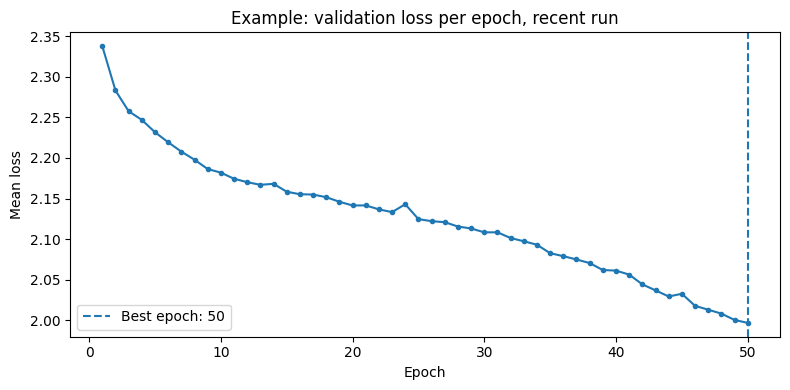

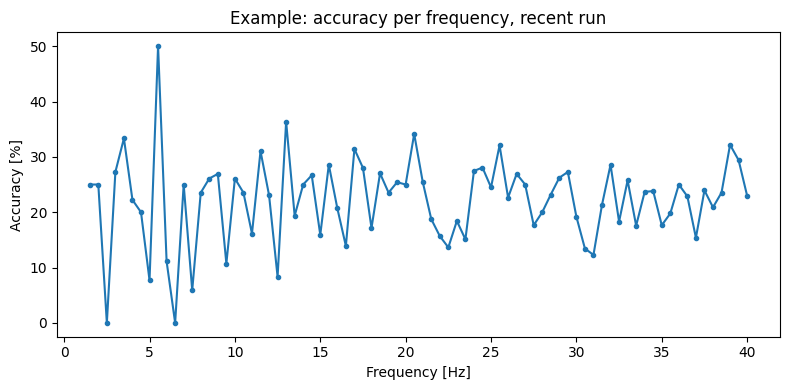

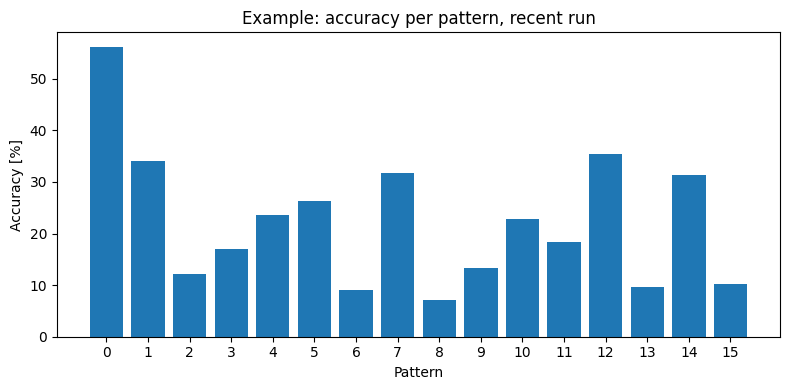

In [9]:
# Benchmarking: best epoch from the most recent example run

import numpy as np
import matplotlib.pyplot as plt

if "validation_losses" not in globals() or len(validation_losses) == 0:
    raise RuntimeError("No validation_losses found. Run the training cell first.")

if "validation_predictions" not in globals() or len(validation_predictions) == 0:
    raise RuntimeError("No validation_predictions found. Run the training cell first.")

# Find best validation-loss epoch from this run
val_keys = sorted(validation_losses.keys(), key=lambda x: int(x.split("_")[1]))
val_epochs = [int(k.split("_")[1]) for k in val_keys]
epoch_losses = [np.mean(validation_losses[k]) for k in val_keys]

best_epoch_key = min(
    validation_losses.keys(),
    key=lambda k: np.mean(validation_losses[k])
)

best_epoch = int(best_epoch_key.split("_")[1])
best_val_loss = np.mean(validation_losses[best_epoch_key])

print("Benchmarking recent example run")
print(f"Best epoch in recent run: {best_epoch}")
print(f"Best validation loss in recent run: {best_val_loss:.4f}")

# Accuracy from stored predictions of the best recent epoch
predictions = np.array(validation_predictions[best_epoch_key])
true_labels = Zval[:, 1]

accuracy = predictions == true_labels
overall_acc = accuracy.mean() * 100

print(f"Overall validation accuracy using best epoch from recent example run: {overall_acc:.2f}%")

# Plot validation loss across epochs
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(val_epochs, epoch_losses, marker="o", markersize=3)
ax.axvline(best_epoch, linestyle="--", label=f"Best epoch: {best_epoch}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean loss")
ax.set_title("Example: validation loss per epoch, recent run")
ax.legend()
fig.tight_layout()
plt.show()

# Accuracy per frequency
frequencies = Zval[:, 0]
unique_freqs = np.unique(frequencies)

frequency_accuracies = np.array([
    accuracy[frequencies == f].mean() * 100
    for f in unique_freqs
])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(unique_freqs, frequency_accuracies, marker="o", markersize=3)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Accuracy [%]")
ax.set_title("Example: accuracy per frequency, recent run")
fig.tight_layout()
plt.show()

# Accuracy per pattern across all frequencies
patterns = Zval[:, 1]
unique_patterns = np.unique(patterns)

pattern_accuracies = np.array([
    accuracy[patterns == p].mean() * 100
    for p in unique_patterns
])

x = np.arange(len(unique_patterns))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x, pattern_accuracies)
ax.set_xticks(x)
ax.set_xticklabels(unique_patterns.astype(int).astype(str))
ax.set_xlabel("Pattern")
ax.set_ylabel("Accuracy [%]")
ax.set_title("Example: accuracy per pattern, recent run")
fig.tight_layout()
plt.show()

Benchmarking all-time best example model on cuda:0.
Loaded all-time best example checkpoint
Best validation loss: 1.9967166185379028
Best epoch: 50
Run name: example_run
Overall validation accuracy using all-time best example model: 22.56%


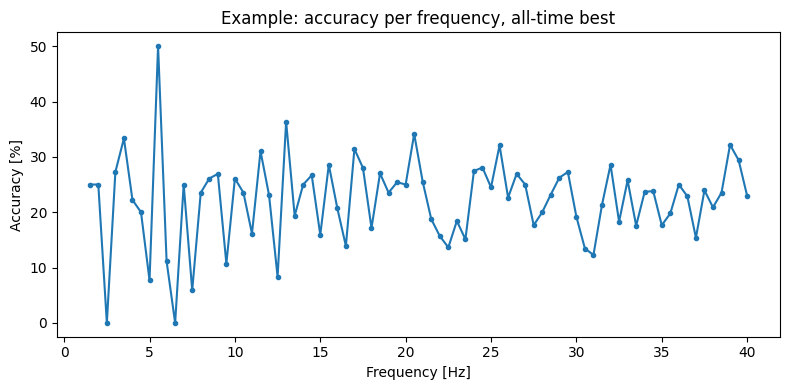

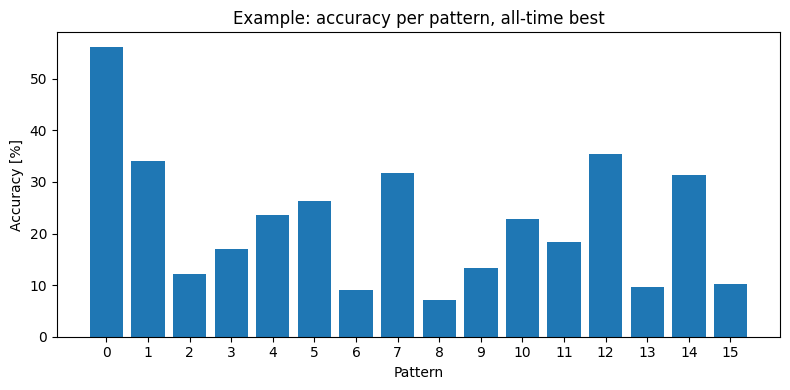

In [10]:
# Benchmarking: all-time best example model

import os
import getpass
import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Benchmarking all-time best example model on {device}.")

best_model_path = f"/home/{getpass.getuser()}/best_model_example.pth"

if not os.path.exists(best_model_path):
    raise FileNotFoundError(f"No saved best example model found at: {best_model_path}")

checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])

    print("Loaded all-time best example checkpoint")
    print("Best validation loss:", checkpoint.get("best_val_loss", "unknown"))
    print("Best epoch:", checkpoint.get("best_epoch", "unknown"))
    print("Run name:", checkpoint.get("run_name", "unknown"))
else:
    model.load_state_dict(checkpoint)
    print("Loaded old-format example model state_dict.")
    print("Warning: no best_val_loss metadata available.")

model.to(device)
model.eval()

# Recompute validation predictions with loaded all-time best model
all_preds = []

with torch.no_grad():
    for x, y, z in val_loader:
        x = x.to(device)

        pred = model(x)
        pred_class = torch.argmax(pred, dim=-1)

        all_preds.append(pred_class.detach().cpu().numpy())

all_preds = np.concatenate(all_preds)

true_labels = Zval[:, 1]
accuracy = all_preds == true_labels
overall_acc = accuracy.mean() * 100

print(f"Overall validation accuracy using all-time best example model: {overall_acc:.2f}%")

# Accuracy per frequency
frequencies = Zval[:, 0]
unique_freqs = np.unique(frequencies)

frequency_accuracies = np.array([
    accuracy[frequencies == f].mean() * 100
    for f in unique_freqs
])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(unique_freqs, frequency_accuracies, marker="o", markersize=3)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Accuracy [%]")
ax.set_title("Example: accuracy per frequency, all-time best")
fig.tight_layout()
plt.show()

# Accuracy per pattern across all frequencies
patterns = Zval[:, 1]
unique_patterns = np.unique(patterns)

pattern_accuracies = np.array([
    accuracy[patterns == p].mean() * 100
    for p in unique_patterns
])

x = np.arange(len(unique_patterns))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x, pattern_accuracies)
ax.set_xticks(x)
ax.set_xticklabels(unique_patterns.astype(int).astype(str))
ax.set_xlabel("Pattern")
ax.set_ylabel("Accuracy [%]")
ax.set_title("Example: accuracy per pattern, all-time best")
fig.tight_layout()
plt.show()

# 5. Submitting predictions

In [ ]:
import os
import getpass
import torch

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
best_model_path = f"/home/{getpass.getuser()}/best_model_example.pth"

if not os.path.exists(best_model_path):
    raise FileNotFoundError(f"No saved best example model found at: {best_model_path}")

checkpoint = torch.load(best_model_path, weights_only=False, map_location=device)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
    print("Loaded all-time best example model.")
    print("Best validation loss:", checkpoint.get("best_val_loss", "unknown"))
    print("Best epoch:", checkpoint.get("best_epoch", "unknown"))
else:
    model.load_state_dict(checkpoint)
    print("Loaded old-format example model state_dict.")

model.to(device)
model.eval()